## Single-asset climate deep-dive

Companion to `portfolio-screening-east-texas.ipynb`. Instead of screening a portfolio, this notebook walks through one asset and pulls every variable Emmi publishes for it: intensity, probability, AAL, fire-danger-days, wind speed, depth, across baseline + four RCP scenarios.

We pick **Channelview Cogeneration Plant**, on the Houston Ship Channel. It's the most multi-hazard-exposed asset in the East Texas portfolio:

* **Wildfire**: nonzero from East Texas fire weather
* **Tropical cyclones**: Gulf coast, directly in the storm track
* **Fluvial flooding**: the only asset in the portfolio with nonzero fluvial-flood AAL at a 1 ha AOI (it sits on the Ship Channel)
* **Coastal flooding**: zero at this point. Coastal-flood mapping at 0.1° resolution doesn't reach Channelview's pixel even though it's on the Bay. See the caveat below.

> **About zeros in CHD floods:** the coastal-flood and fluvial-flood datasets only have nonzero values at pixels Emmi has modelled for storm-surge / river-flood exposure. With a 1 ha point AOI, a small offset can put you on a pixel that isn't flood-mapped (so you see zero), even if a neighbouring pixel is. To screen for flood risk at scale, either pick AOIs that are on the coast/in a flood plain, or use a larger AOI (e.g. 100 ha) that intersects multiple grid cells.

Uses `chd.load()` + `chd.sample()` directly (the lower-level primitives), rather than the one-call `chd.screen()`. Subscriptions are reused from the portfolio notebook's `tag="emmi-chd-example"` namespace, so this notebook costs nothing if you've already run it.

### Prereqs

Same as the portfolio notebook: `cecil`, `pandas`, `matplotlib`, and `CECIL_API_KEY` in the environment.

### 1. Connect

In [1]:
import os
import logging

import cecil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chd

logging.basicConfig(level=logging.INFO, format="%(message)s")
assert os.environ.get("CECIL_API_KEY"), "Set CECIL_API_KEY in your environment first."
client = cecil.Client()

### 2. Pick the asset and provision

One-row DataFrame so we can reuse `chd.provision()` unchanged. The `tag` matches the portfolio notebook's, so if you've already run that, this is a no-op reuse.

In [2]:
ASSET = pd.DataFrame([
    {"name": "Channelview", "lat": 29.837, "lon": -95.122, "value_usd": 900_000_000},
])

subs = chd.provision(client, ASSET, target_ha=1.0, tag="emmi-chd-example")
sub_by_hazard = subs["Channelview"]

  = AOI reused    Channelview                  (1.002 ha)
AOIs:            1 total  (0 new, 1 reused)
Subscriptions:   4 total  (0 new, 4 reused)


### 3. What variables can we ask about?

Use `chd.list_variables(hazard=...)` to see the catalogue per hazard. Different hazards publish different metrics (e.g. only wildfire publishes `fire_danger_days`, only cyclones publishes `wind_speed_mps`, only floods publish `depth_meters`).

In [3]:
for hazard in chd.DATASETS:
    metrics_here = [m for m, hazards in chd.METRICS.items() if hazard in hazards]
    print(f"{hazard:<16} metrics: {metrics_here}")

wildfire         metrics: ['average_annual_loss', 'intensity', 'probability', 'fire_danger_days']
cyclones         metrics: ['average_annual_loss', 'intensity', 'probability', 'wind_speed_mps']
coastal_floods   metrics: ['average_annual_loss', 'intensity', 'probability', 'depth_meters']
fluvial_floods   metrics: ['average_annual_loss', 'intensity', 'probability', 'depth_meters']


### 4. Sample every (hazard, metric, scenario, year) for this asset

Walk the catalogue and call `chd.sample()` on each loaded subscription. The result is a long-format DataFrame, one row per measurement. Cached `chd.load()` means each hazard's dataset is opened once.

In [4]:
cache = {}
rows = []
for hazard, sub in sub_by_hazard.items():
    ds = chd.load(client, sub, cache=cache)
    for metric, hazards_with_metric in chd.METRICS.items():
        if hazard not in hazards_with_metric:
            continue
        for scenario in chd.SCENARIOS_BY_HAZARD[hazard]:
            years = [chd.BASELINE_YEAR] if scenario == "baseline" else chd.VALID_FUTURE_YEARS
            for year in years:
                value = chd.sample(ds, f"{metric}_{scenario}",
                                   year=year if scenario != "baseline" else None)
                rows.append({"hazard": hazard, "metric": metric,
                             "scenario": scenario, "year": year, "value": value})

df = pd.DataFrame(rows)
df.head(10)

,hazard,metric,scenario,year,value
0,wildfire,average_annual_loss,baseline,1980,0.001523
1,wildfire,average_annual_loss,rcp2p6,2030,0.001735
2,wildfire,average_annual_loss,rcp2p6,2050,0.001755
3,wildfire,average_annual_loss,rcp2p6,2080,0.001856
4,wildfire,average_annual_loss,rcp4p5,2030,0.001810
5,wildfire,average_annual_loss,rcp4p5,2050,0.001987
6,wildfire,average_annual_loss,rcp4p5,2080,0.002234
7,wildfire,average_annual_loss,rcp6p0,2030,0.001566
8,wildfire,average_annual_loss,rcp6p0,2050,0.001684
9,wildfire,average_annual_loss,rcp6p0,2080,0.001710


### 5. Per-metric trajectory chart

One panel per (hazard, metric). Lines are the four RCP scenarios + the baseline anchor at 1980. Some panels are flat (e.g. fluvial flood probability under low warming) and some explode (wildfire AAL under RCP8.5).

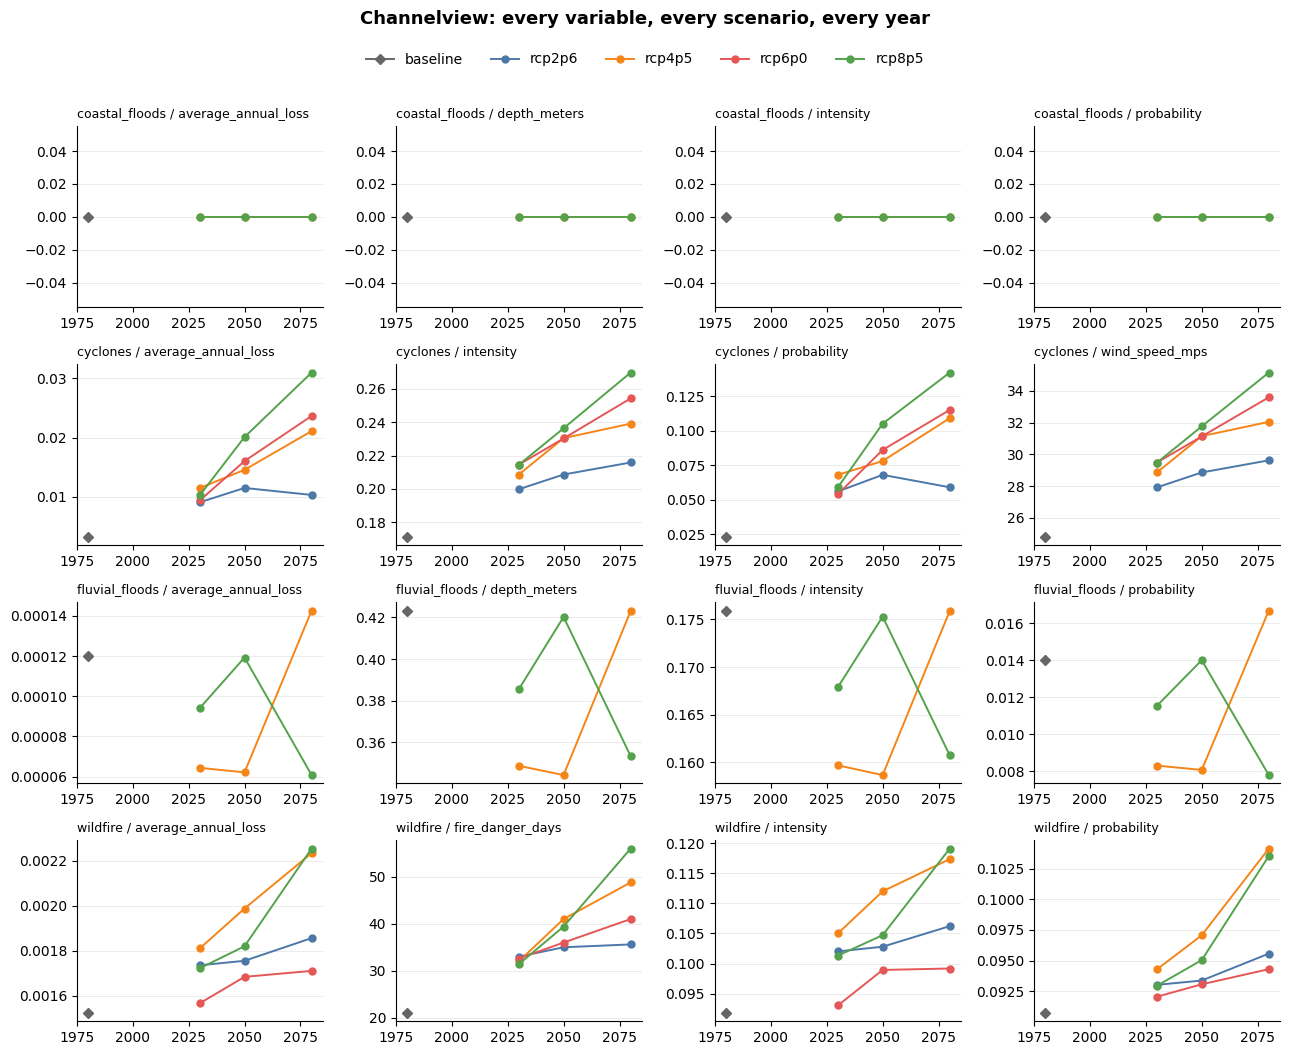

In [5]:
SCENARIO_COLORS = {
    "baseline": "#666666",
    "rcp2p6":   "#4c78a8",
    "rcp4p5":   "#f58518",
    "rcp6p0":   "#e45756",
    "rcp8p5":   "#54a24b",
}

# Build a (hazard, metric) panel grid for everything in the data.
panels = sorted({(r.hazard, r.metric) for r in df.itertuples()})
ncols = 4
nrows = (len(panels) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 2.5 * nrows))
axes = axes.flatten()

for ax, (hazard, metric) in zip(axes, panels):
    panel = df[(df["hazard"] == hazard) & (df["metric"] == metric)]
    for scenario, color in SCENARIO_COLORS.items():
        s_data = panel[panel["scenario"] == scenario].sort_values("year")
        if s_data.empty or s_data["value"].isna().all():
            continue
        marker = "D" if scenario == "baseline" else "o"
        ax.plot(s_data["year"], s_data["value"], marker=marker, linewidth=1.4,
                color=color, label=scenario, markersize=5)
    ax.set_title(f"{hazard} / {metric}", fontsize=9, loc="left")
    ax.grid(axis="y", color="0.92", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

for ax in axes[len(panels):]:
    ax.set_visible(False)

handles = [plt.Line2D([0], [0], color=c, marker=("D" if s == "baseline" else "o"),
                       linewidth=1.4, markersize=5, label=s)
           for s, c in SCENARIO_COLORS.items()]
fig.legend(handles=handles, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Channelview: every variable, every scenario, every year",
             fontsize=13, fontweight="semibold", y=1.05)
plt.tight_layout()
plt.show()

### 6. Where is the biggest climate-attributable shift?

Pivot the DataFrame to compute the delta (RCP8.5 @ 2080 minus baseline) per (hazard, metric). Ranks which dimensions of risk move the most under a worst-case future.

In [6]:
wide = df.pivot_table(
    index=["hazard", "metric"],
    columns=["scenario", "year"],
    values="value",
    aggfunc="first",
)

baseline = wide[("baseline", chd.BASELINE_YEAR)]
worst_case = wide[("rcp8p5", 2080)]
delta = (worst_case - baseline).dropna().sort_index()

delta.to_frame("rcp8p5_2080_minus_baseline")

rcp8p5_2080_minus_baseline
hazard         metric                                         
coastal_floods average_annual_loss                    0.000000
               depth_meters                           0.000000
               intensity                              0.000000
               probability                            0.000000
cyclones       average_annual_loss                    0.027791
               intensity                              0.098297
               probability                            0.118995
               wind_speed_mps                        10.353498
fluvial_floods average_annual_loss                   -0.000059
               depth_meters                          -0.069956
               intensity                             -0.015193
               probability                           -0.006244
wildfire       average_annual_loss                    0.000731
               fire_danger_days                      35.000000
               intensity                              0.027271
               probability                            0.012807

### Next steps

* **A different asset.** Try changing the `ASSET` row in section 2.
* **Compare two assets.** Run sections 2-5 twice with different `ASSET` rows and overlay.
* **Custom variable filter.** `chd.list_variables(metric="fire_danger_days")` to focus on one metric across hazards (where applicable).